In [2]:
import numpy as np
import h5py
import time

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from dataset_generation.gw_class_gen import *
from helpers.config import *
from helpers.glitch_shapes import *

from lisaglitch import LPFLibraryGlitch, ShapeletGlitch, Glitch
from lisainstrument import Instrument

import warnings
warnings.filterwarnings("ignore")

In [2]:
def make_tdi_dict(X, Y, Z, whiten=True):
    A, E, T = get_AET(X, Y, Z)

    tdi_dict = {}
    channel_names = ['X', 'Y', 'Z', 'A', 'E', 'T']
    channel_data = [X, Y, Z, A, E, T]
    for i, name in enumerate(channel_names):
        if whiten:
            psd_data = np.load(PSD_PATH / f'psd_{name}.npz')
            f_psd, psd = psd_data['f_psd'], psd_data['psd']
            tdi_dict[name] = whiten_with_psd(channel_data[i], dt=0.25, f_psd=f_psd, psd=psd, alpha=0.1)
        else:
            tdi_dict[name] = channel_data[i]
    return tdi_dict

In [120]:
glitch_param_path = DIST / 'glitch_params_ordinary.txt'
data = np.loadtxt(glitch_param_path, skiprows=1)

betas = data[:, 0]
levels = data[:, 1]
snrs = data[:, 2]

levels = levels[betas < 500]
betas = betas[betas < 500]

In [131]:
levels, betas

(array([ 2.49834508e-13,  2.87276039e-13, -6.99824190e-14, ...,
        -2.68982420e-13,  1.08805870e-12,  2.14877413e-08]),
 array([ 0.86657307,  0.37766861, 14.59371378, ...,  0.27091507,
         4.56240462, 65.07520903]))

In [136]:
real_glitch_path = str(DIST / 'real_glitch_output.h5')
pipe = {'t0':10368000, 'dt':0.25, 'size':10*3600/0.25}

glitches = [{'type':'ShapeletGlitch', 't_inj': 5*3600, 'beta':betas[2],
             'level':1e4*levels[2], 'inj_point':'tm_12'}]
#glitches = [{'type':'OneSidedDoubleExpGlitch', 't_inj': 0,
 #            'level':0, 't_rise':1, 't_fall':1, 'inj_point':'tm_23'}]
#glitches = [{'type':'RealGlitch', 't_inj': 5*3600, 'scale':1e5,
 #            'run':3, 'index':2, 'inj_point':'tm_23'}]

gws = [{'type':'ReducedOneSidedDoubleExpGW', 't_inj': 0, 'amp':0, 't_rise':1, 't_fall':1,
        'gw_beta':0.02*np.pi, 'gw_lambda':0.98*np.pi}]
#gws = [{'type': 'BinaryInspiralGW', 'm1': 1e5, 'm2': 1e5, 'd': 3e3,
 #       'spin1': 0.42, 'spin2': -0.42, 't_inj': 5.9*3600, 'domain': 'freq', 'gw_beta':0.09*np.pi, 'gw_lambda':1.09*np.pi}]

In [137]:
run_simulation(gws, glitches, pipe,
                gw_path, glitch_path, orbits_path, simulation_path, disable_noise=False)
raw_dict = run_tdi(simulation_path, pipe)

You are using an orbit file in a version that might not be fully supported
You are using an orbit file in a version that might not be fully supported
You are using a glitch file in a version that might not be fully supported


In [124]:
specs = {'low_mass': {'trange':(-3, 3), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(29, 31, 5), 'Q':30,
                      'drange':np.logspace(3, 4, 5)},
         'high_mass': {'trange':(-3, 3), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(15, 17, 5), 'Q':16,
                      'drange':np.logspace(3, 5, 5)},
         'ext_high_mass': {'trange':(-3, 3), 'frange':(1e-4, 1e-2), 
                       'Qvals':np.linspace(5, 7, 5), 'Q':10,
                       'drange':np.logspace(4, 5, 5)}}

In [138]:
event = glitches[0]
channel = 'A'
res = 256
spec = specs['high_mass']
tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=True)

start = time.time()
#t_arr, f_arr, varQT = varq_transform(tdi_dict, channel, pipe, event, resolution=res,
 #                            frange=spec['frange'], trange=spec['trange'], Qvals=spec['Qvals'])
t_arr2, f_arr2, QT = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Q=spec['Q'])
end = time.time()
print(end - start)

0.5605242252349854


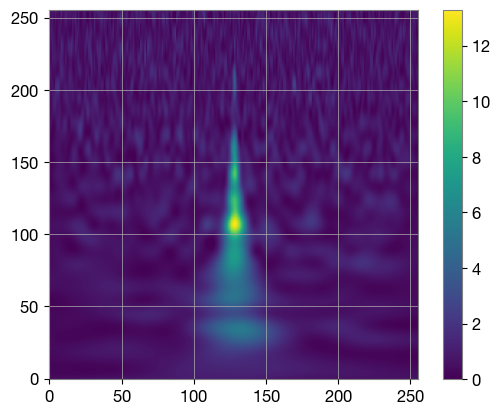

In [139]:
plt.imshow(QT, origin='lower')
#plt.clim(0, 90)
plt.colorbar()
plt.show()

In [140]:
path = str(DIST / 'lpf-glitch-library.h5')
glitch = LPFLibraryGlitch(path=path, inj_point='tm_12', t0=pipe['t0'], t_inj=1*3600+ pipe['t0'], run=3, glitch=2)

#glitch.write(real_glitch_path)

In [ ]:
h5 = h5py.File(path, "r")

run_no = 1
glitch_no = 1
key = f'timeseries/run{run_no:02d}/glitch{glitch_no:02d}'
count = 0
while run_no <= 76:
    key = f'timeseries/run{run_no:02d}/glitch{glitch_no:02d}'
    if key in h5:
        count += 1
        print(key)
    glitch_no += 1
    if key not in h5:
        run_no += 1
        glitch_no = 1

h5.close()
print(count)

timeseries/run01/glitch01
timeseries/run01/glitch02
timeseries/run01/glitch03
timeseries/run01/glitch04
timeseries/run01/glitch05
timeseries/run01/glitch06
timeseries/run01/glitch07
timeseries/run01/glitch08
timeseries/run01/glitch09
timeseries/run01/glitch10
timeseries/run01/glitch11
timeseries/run02/glitch01
timeseries/run03/glitch01
timeseries/run03/glitch02
timeseries/run04/glitch01
timeseries/run06/glitch01
timeseries/run06/glitch02
timeseries/run08/glitch01
timeseries/run08/glitch02
timeseries/run09/glitch01
timeseries/run09/glitch02
timeseries/run09/glitch03
timeseries/run09/glitch04
timeseries/run09/glitch05
timeseries/run09/glitch06
timeseries/run09/glitch07
timeseries/run09/glitch08
timeseries/run12/glitch01
timeseries/run12/glitch02
timeseries/run12/glitch03
timeseries/run13/glitch01
timeseries/run13/glitch02
timeseries/run14/glitch01
timeseries/run17/glitch01
timeseries/run17/glitch02
timeseries/run17/glitch03
timeseries/run18/glitch01
timeseries/run18/glitch02
timeseries/r

In [141]:
def print_structure(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"{name}  (Dataset)  shape={obj.shape}  dtype={obj.dtype}")
    else:
        print(f"{name}  (Group)")

with h5py.File(path, "r") as f:
    f.visititems(print_structure)

legacy_params  (Group)
legacy_params/run01  (Group)
legacy_params/run01/glitch01  (Dataset)  shape=(5, 1)  dtype=float64
legacy_params/run01/glitch02  (Dataset)  shape=(5, 1)  dtype=float64
legacy_params/run01/glitch03  (Dataset)  shape=(5, 1)  dtype=float64
legacy_params/run01/glitch04  (Dataset)  shape=(5, 1)  dtype=float64
legacy_params/run01/glitch05  (Dataset)  shape=(5, 1)  dtype=float64
legacy_params/run01/glitch06  (Dataset)  shape=(5, 1)  dtype=float64
legacy_params/run01/glitch07  (Dataset)  shape=(5, 1)  dtype=float64
legacy_params/run01/glitch08  (Dataset)  shape=(5, 1)  dtype=float64
legacy_params/run01/glitch09  (Dataset)  shape=(5, 1)  dtype=float64
legacy_params/run01/glitch10  (Dataset)  shape=(5, 1)  dtype=float64
legacy_params/run01/glitch11  (Dataset)  shape=(5, 1)  dtype=float64
legacy_params/run02  (Group)
legacy_params/run02/glitch01  (Dataset)  shape=(5, 1)  dtype=float64
legacy_params/run03  (Group)
legacy_params/run03/glitch01  (Dataset)  shape=(5, 1)  dtype=f

In [4]:
data = np.loadtxt(DIST / 'glitch_params_cold.txt', skiprows=1)
data.shape

(153, 3)